##### 1. Load Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

##### 2. Load and Add Target Columns (normalized from preprocessing notebook)
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def read_all_csvs_to_df(folder_path):
    loaded_files = []

    file_list = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))
    if not file_list:
        raise ValueError(f"No CSV files found in folder: {folder_path}")

    for file_name in file_list:
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        loaded_files.append((file_name, df, target_value))

    min_feature_cols = min(df.shape[1] for _, df, _ in loaded_files)
    dataframes = []

    for i, (file_name, df, target_value) in enumerate(loaded_files):
        if df.shape[1] > min_feature_cols:
            print(f"Trimming {file_name} from {df.shape[1]} to {min_feature_cols} spectral columns.")
            df = df.iloc[:, :min_feature_cols]

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        df = df.copy()
        df["target"] = target_value
        dataframes.append(df)

    combined_df = pd.concat(dataframes, ignore_index=True).copy()

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_path = os.path.join("..", "data", "mixed_ratio")
df = read_all_csvs_to_df(folder_path)

# for testing
#print(df.head())

Trimming g_mixed_1-9_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_3_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_4_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_3_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_4_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_5-5_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_5-5_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 38

##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
def label_data(dataframe):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df

clean_df = label_data(df)

#for testing
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Implement ICA

In [4]:
def fit_fast_ica(dataframe, target_col="target_encoded", n_components=5, random_state=42, max_iter=5000, tol=1e-4):
    def _resolve_metadata_path(filename):
        candidate_paths = [
            os.path.join(os.getcwd(), filename),
            os.path.join(os.getcwd(), "Analysis", "ICA", filename),
        ]
        for path in candidate_paths:
            if os.path.exists(path):
                return path
        raise FileNotFoundError(f"Could not locate {filename} from the current working directory.")

    if target_col not in dataframe.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    feature_cols = [col for col in dataframe.columns if col != target_col]
    if not feature_cols:
        raise ValueError("No feature columns were found for ICA.")

    X = dataframe[feature_cols].to_numpy(dtype=float)
    y = dataframe[target_col].to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_components = min(n_components, X_scaled.shape[0], X_scaled.shape[1])
    if n_components < 1:
        raise ValueError("n_components must be at least 1 after accounting for data shape.")

    ica = FastICA(
        n_components=n_components,
        whiten="unit-variance",
        algorithm="parallel",
        fun="logcosh",
        random_state=random_state,
        max_iter=max_iter,
        tol=tol,
    )

    source_scores = ica.fit_transform(X_scaled)
    mixing_matrix = ica.mixing_
    component_spectra = ica.components_.copy()

    source_mean = source_scores.mean(axis=0)
    source_std = source_scores.std(axis=0, ddof=0)
    source_std[source_std == 0] = 1
    source_kurtosis = np.mean(((source_scores - source_mean) / source_std) ** 4, axis=0) - 3

    component_order = np.argsort(np.abs(source_kurtosis))[::-1]
    source_scores = source_scores[:, component_order]
    mixing_matrix = mixing_matrix[:, component_order]
    component_spectra = component_spectra[component_order, :]
    source_kurtosis = source_kurtosis[component_order]

    for i in range(component_spectra.shape[0]):
        peak_idx = np.argmax(np.abs(component_spectra[i]))
        sign = np.sign(component_spectra[i, peak_idx])
        if sign == 0:
            sign = 1
        component_spectra[i] *= sign
        source_scores[:, i] *= sign
        mixing_matrix[:, i] *= sign

    with open(_resolve_metadata_path("target_encoding_map.json"), "r") as f:
        target_map_raw = json.load(f)
    target_map = {v: k for k, v in target_map_raw.items()}

    with open(_resolve_metadata_path("feature_map.json"), "r") as f:
        feature_map_raw = json.load(f)
    wavenumbers = np.array([float(feature_map_raw[str(col)]) for col in feature_cols])

    scores_df = pd.DataFrame(
        source_scores,
        columns=[f"IC{i+1}" for i in range(source_scores.shape[1])]
    )
    scores_df[target_col] = y
    scores_df["target_label"] = [target_map[val] for val in y]

    print(f"FastICA fitted with {n_components} components.")
    print(f"Spectral matrix shape: {X.shape}")
    print("Components ordered by |excess kurtosis|:")
    for i, kurt in enumerate(source_kurtosis, start=1):
        print(f"  IC{i}: kurtosis = {kurt:.3f}")

    return {
        "ica_model": ica,
        "scaler": scaler,
        "feature_columns": feature_cols,
        "wavenumbers": wavenumbers,
        "scores": source_scores,
        "scores_df": scores_df,
        "mixing_matrix": mixing_matrix,
        "component_spectra": component_spectra,
        "source_kurtosis": source_kurtosis,
        "targets": y,
        "target_map": target_map,
        "target_col": target_col,
    }


ica_results = fit_fast_ica(clean_df, target_col="target_encoded", n_components=5)
ica_df = ica_results["scores_df"]
ica_model = ica_results["ica_model"]
ica_scaler = ica_results["scaler"]


FastICA fitted with 5 components.
Spectral matrix shape: (61754, 388)
Components ordered by |excess kurtosis|:
  IC1: kurtosis = 12.114
  IC2: kurtosis = 10.191
  IC3: kurtosis = 3.754
  IC4: kurtosis = 1.713
  IC5: kurtosis = -1.026


##### 5. Visualize the ICA

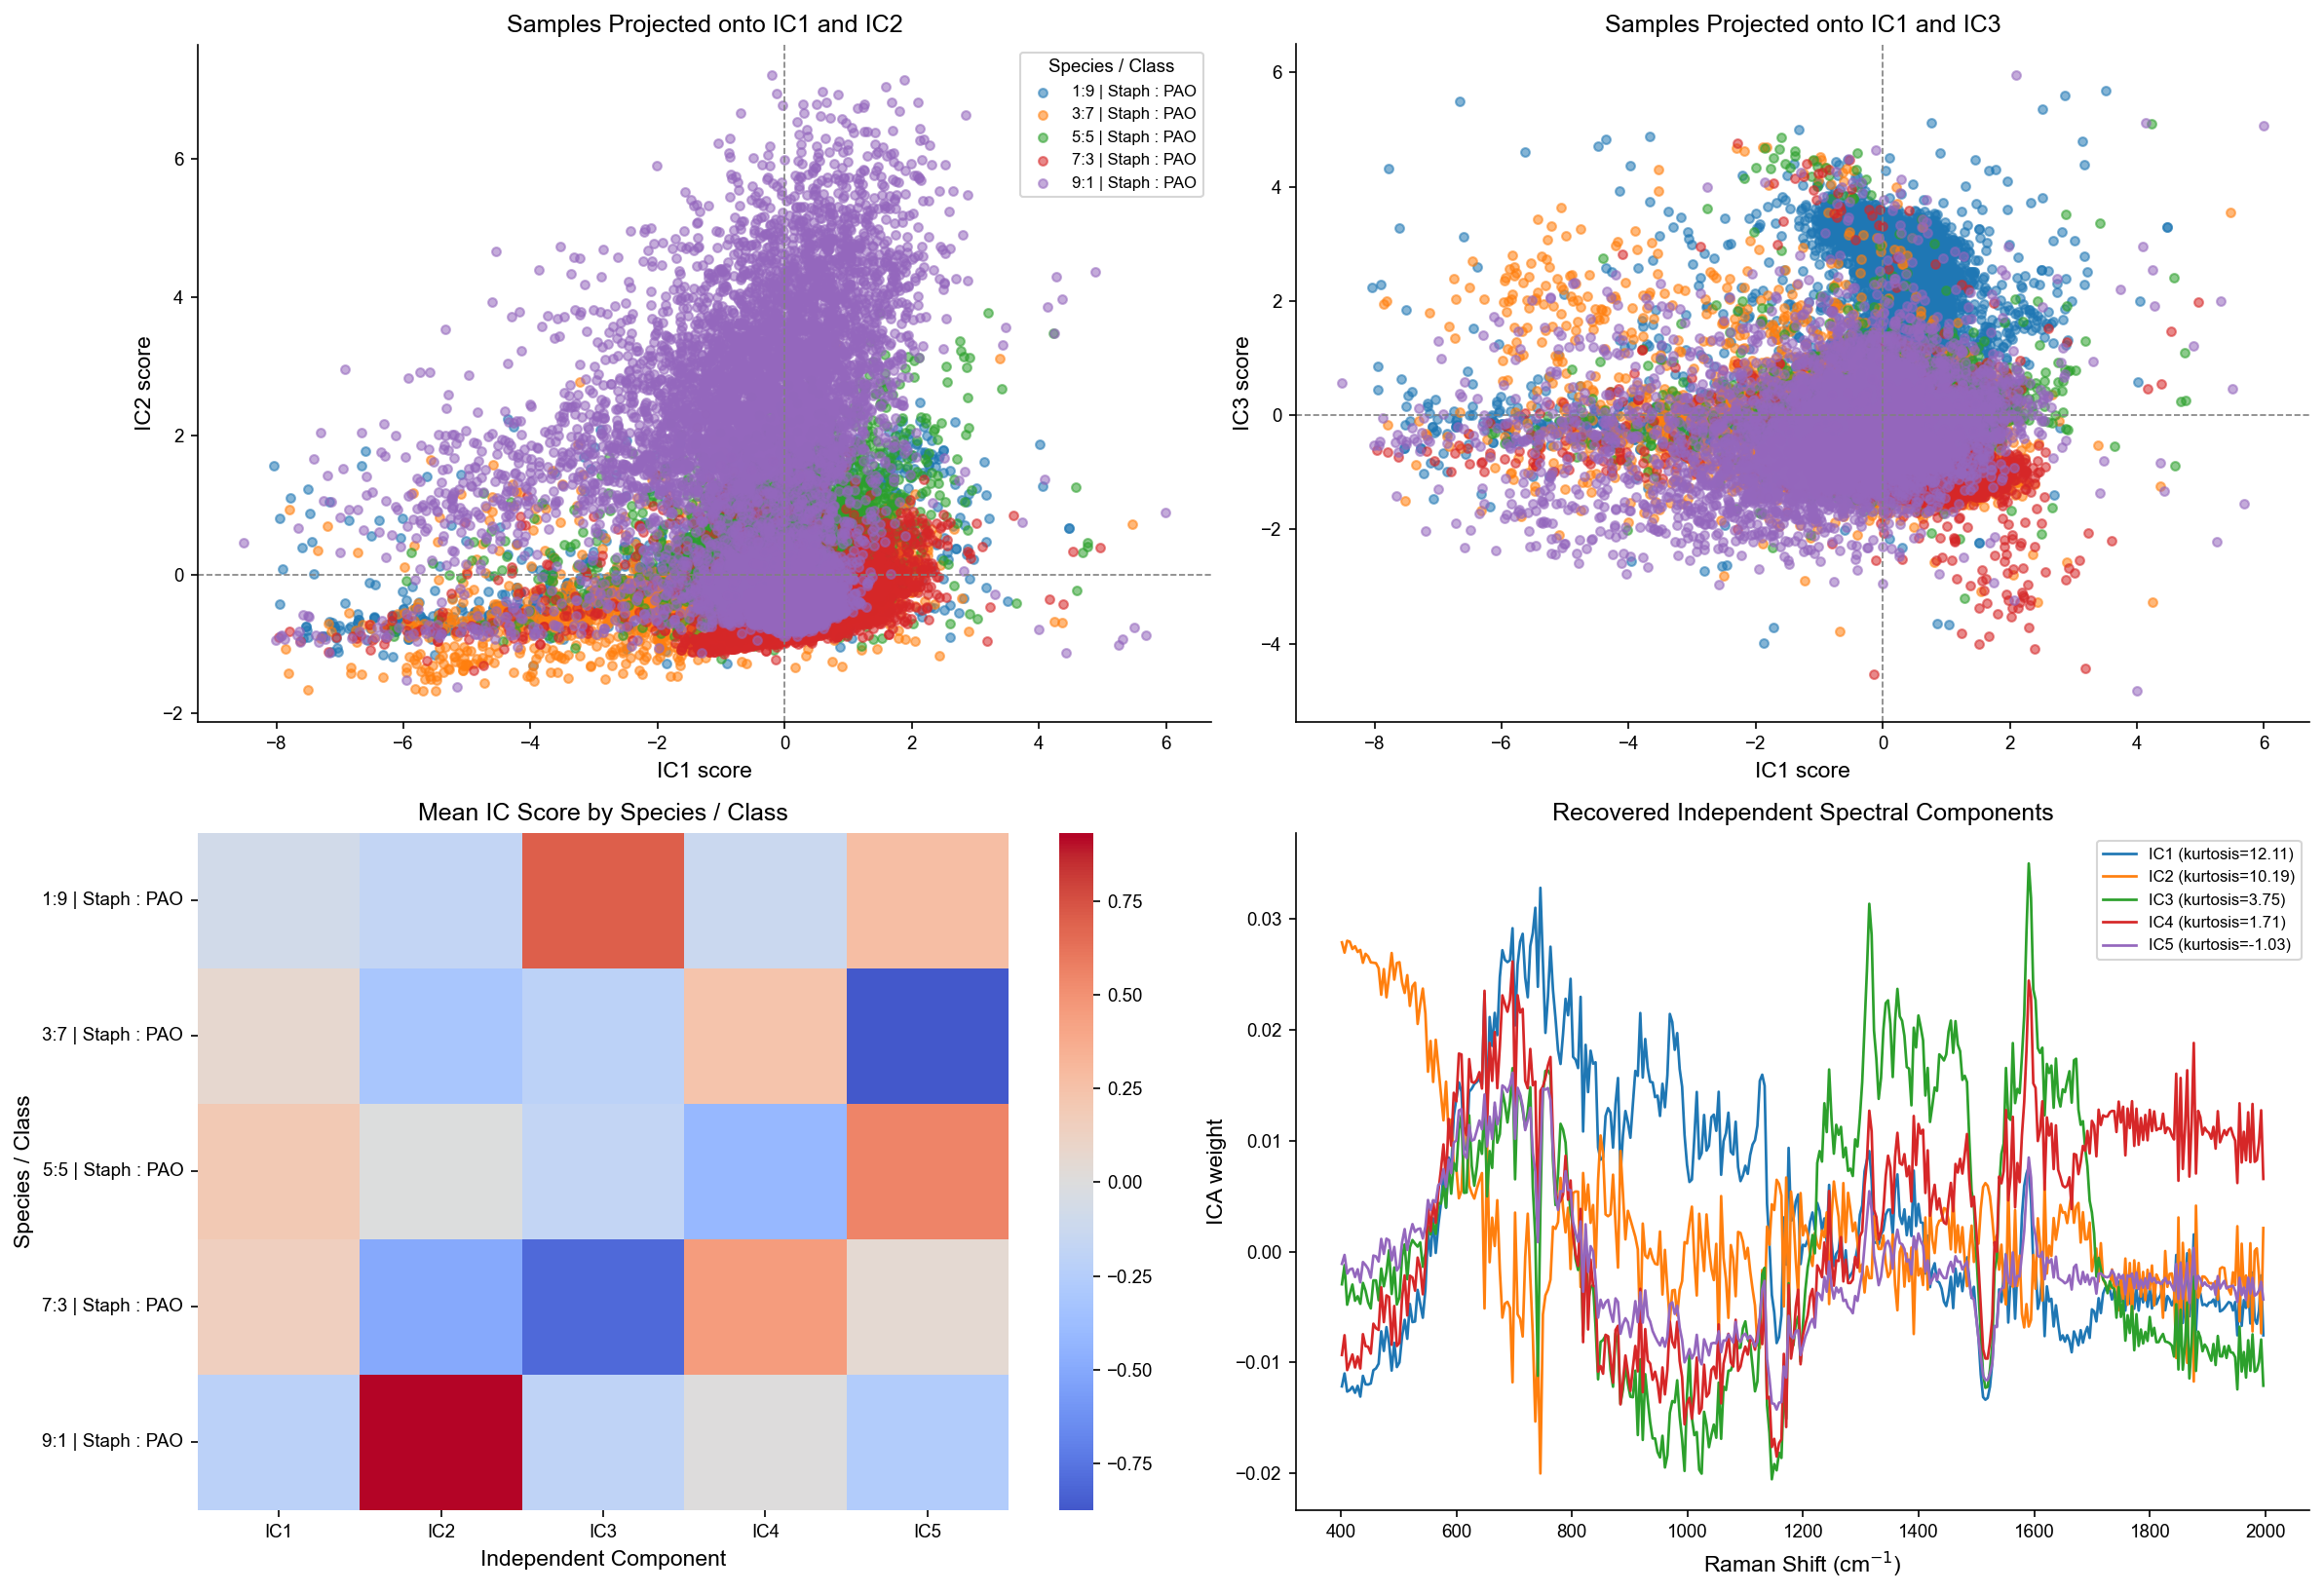

In [5]:
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})

scores_df = ica_results["scores_df"]
wavenumbers = ica_results["wavenumbers"]
component_spectra = ica_results["component_spectra"]
source_kurtosis = ica_results["source_kurtosis"]
target_col = ica_results["target_col"]
target_map = ica_results["target_map"]

unique_groups = sorted(scores_df[target_col].unique())
palette = sns.color_palette("tab10", n_colors=len(unique_groups))
group_colors = {grp: palette[i] for i, grp in enumerate(unique_groups)}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax = axes[0, 0]
for grp in unique_groups:
    grp_df = scores_df[scores_df[target_col] == grp]
    ax.scatter(
        grp_df["IC1"],
        grp_df["IC2"],
        s=18,
        alpha=0.55,
        color=group_colors[grp],
        label=target_map[grp],
    )
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("IC1 score")
ax.set_ylabel("IC2 score")
ax.set_title("Samples Projected onto IC1 and IC2")
ax.legend(title="Species / Class", fontsize=8, title_fontsize=9, loc="best")

ax = axes[0, 1]
y_axis_component = "IC3" if "IC3" in scores_df.columns else "IC2"
for grp in unique_groups:
    grp_df = scores_df[scores_df[target_col] == grp]
    ax.scatter(
        grp_df["IC1"],
        grp_df[y_axis_component],
        s=18,
        alpha=0.55,
        color=group_colors[grp],
    )
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("IC1 score")
ax.set_ylabel(f"{y_axis_component} score")
ax.set_title(f"Samples Projected onto IC1 and {y_axis_component}")

ax = axes[1, 0]
mean_scores = scores_df.groupby("target_label")[[col for col in scores_df.columns if col.startswith("IC")]].mean()
sns.heatmap(mean_scores, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Mean IC Score by Species / Class")
ax.set_xlabel("Independent Component")
ax.set_ylabel("Species / Class")

ax = axes[1, 1]
n_plot = min(5, component_spectra.shape[0])
for i in range(n_plot):
    ax.plot(
        wavenumbers,
        component_spectra[i],
        linewidth=1.3,
        label=f"IC{i+1} (kurtosis={source_kurtosis[i]:.2f})"
    )
ax.set_xlabel("Raman Shift (cm$^{-1}$)")
ax.set_ylabel("ICA weight")
ax.set_title("Recovered Independent Spectral Components")
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()
